# Import packages and set up directories

In [ ]:
import os
import pandas as pd
import numpy as np
import gffutils
import glob
from pyfaidx import Fasta
from collections import defaultdict
from tqdm import tqdm

# del visuals
from src import visuals
import omics_utils

## Download reference genome and transcriptome

In [3]:
import os
import gffutils
import os
import gzip
import requests
import omics_utils

# Step 1: Download files from GENcode if not exist

####### Change below as needed ########
rl_version = '49'
db_home = os.path.join(os.path.expanduser('~'), f'database/genomes/gencode')
genome_fasta_path = os.path.join(db_home, 'GRCh37.primary_assembly.genome.fa')
genome_fasta_index_path = genome_fasta_path + '.fai'

gencode_gff3_path = os.path.join(db_home, f'gencode.v{rl_version}lift37.annotation.gff3')
gencode_gtf_path = os.path.join(db_home, f'gencode.v{rl_version}lift37.annotation.gtf')
gencode_gtf_db_path = os.path.join(db_home, os.path.basename(gencode_gtf_path) + '.db')
####### No need to change below (ideally) ########

# Download file from url to local path with requests library
def download_file(url, local_path):
    response = requests.get(url, stream=True)
    with open(local_path, 'wb') as file:
        print(f"Downloading {url}\n to {local_path}...")
        for crop in response.iter_content(crop_size=8192):
            file.write(crop)
    print(f"Downloaded {url}\n to {local_path}")


# Download and unzip file if not exist
for db_path in [genome_fasta_path, gencode_gff3_path, gencode_gtf_path]:
    if not os.path.exists(db_path):
        os.makedirs(db_home, exist_ok=True)
        url = f'https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_{rl_version}/{db_path.split("/")[-1]}.gz'
        # https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_49/gencode.v49.annotation.gtf.gz
        # https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_49/GRCh38.primary_assembly.genome.fa.gz
        local_gz_path = db_path + '.gz'
        download_file(url, local_gz_path)
        with gzip.open(local_gz_path, 'rb') as f_in:
            with open(db_path, 'wb') as f_out:
                f_out.write(f_in.read())
        os.remove(local_gz_path)
    else:
        print(f"File {db_path} already exists. Skipping download.")


# generate fai file from fa file
if not os.path.exists(genome_fasta_index_path):
    print(f"Creating FAI index for {genome_fasta_path}...")
    os.system(f'samtools faidx {genome_fasta_path}')
else:
    print(f"FAI index file exists: {genome_fasta_index_path}")


if not os.path.exists(gencode_gtf_db_path):
    omics_utils.gffutils_create_gencode_db(gencode_gtf_path, gencode_gtf_db_path)
else:
    print(f"GFFUtils database exists: {gencode_gtf_db_path}")

File /home/xqiu/database/genomes/gencode/GRCh37.primary_assembly.genome.fa already exists. Skipping download.
File /home/xqiu/database/genomes/gencode/gencode.v49lift37.annotation.gff3 already exists. Skipping download.
File /home/xqiu/database/genomes/gencode/gencode.v49lift37.annotation.gtf already exists. Skipping download.
FAI index file exists: /home/xqiu/database/genomes/gencode/GRCh37.primary_assembly.genome.fa.fai
GFFUtils database exists: /home/xqiu/database/genomes/gencode/gencode.v49lift37.annotation.gtf.db


## Pangolin_reproduced dataset

In [ ]:

dataset_dir = os.path.join(os.getcwd(), "data/pangolin_reproduced")

tissue_type = "heart"
# tsv_file = os.path.join(os.getcwd(), "data/Human/E-MTAB-6814/spliser_heart.All.DiffSpliSER.tsv")
tsv_file = os.path.join(dataset_dir, f"E-MTAB-6814/spliser_{tissue_type}.combined.tsv")

# check if spliser_df already loaded
if 'spliser_df' not in locals():
    spliser_df = pd.read_csv(tsv_file, sep='\t', comment='#')
else:
    print("spliser_df already loaded. Skipping reading TSV file.")

junc_columns = ['Sample', 'Region', 'Site', 'Strand', 'Gene', 'SSE', 'alpha_count', 'beta1_count', 'beta2_count',
                'MultiGeneFlag', 'Others', 'Partners', 'Competitors']

for col in junc_columns:
    if col not in spliser_df.columns:
        raise ValueError(f"Column {col} not found in the TSV file.")
else:
    print(f"All required columns are present in the TSV file.")

FileNotFoundError: [Errno 2] No such file or directory: '/home/xqiu/bench/rna_predict/ContextSplice/data/pangolin_reproduced/E-MTAB-6814/spliser_heart.combined.tsv'

In [10]:
spliser_gf = spliser_df.groupby('Gene')
gene_ids = list(spliser_gf.groups.keys())
print(f"Total genes with splicing sites: {len(gene_ids)}")

gtf_db = gffutils.FeatureDB(gencode_gtf_db_path, keep_order=True)
omics_utils.check_gene_in_gtf_db(gene_ids, gtf_db)

Total genes with splicing sites: 38096


100%|██████████| 38096/38096 [00:01<00:00, 19300.27it/s]

Found 38095 out of 38096 genes in GTF database.


In [ ]:
# collect splice sites for each gene

try:
    get_ipython
    print("Running in Jupyter Notebook or Ipython")
    genesites_replicates_list = []
    for gene_id in tqdm(gene_ids):
        genesites = omics_utils.spliser_collect_gene_splice_sites(gene_id, gene_gf=spliser_gf, debug=False)
        genesites_replicates_list.append(genesites)
except NameError:
    import functools
    import misc
    genesites_replicates_list = misc.mpi_map(functools.partial(omics_utils.spliser_collect_gene_splice_sites, gene_gf=spliser_gf), tqdm(gene_ids))

genesites_replicates_df = pd.DataFrame(genesites_replicates_list)

# show a random row of genesites_df
print(genesites_replicates_df.sample(n=1).iloc[0])

genesites_replicates_path = os.path.join(dataset_dir, f"genesites_replicates_{tissue_type}.pkl")
genesites_replicates_df.to_pickle(genesites_replicates_path)
print(f"Saved genesites_list to {genesites_replicates_path}")

Running in Jupyter Notebook or Ipython


100%|██████████| 38096/38096 [06:03<00:00, 104.67it/s]


chrom                                                          chr15
strand                                                             -
gene_id                                            ENSG00000294802.1
num_sites                                                          3
site_id                               [78275499, 78275853, 78276074]
site_type                                [acceptor, donor, acceptor]
donor_count                                                [0, 2, 0]
acceptor_count                                             [1, 0, 1]
other              [[78214107, 78293960], [78214107, 78293960], [...
multi_gene_flag                                   [True, True, True]
partner               [[78230147], [ 78290536,78276074], [78275852]]
competitor                    [[], [78287402, 78287405], [78290536]]
num_samples                                                       33
sam_names          [1437sTS.Human.Heart.11w.Male.sorted.sorted, 1...
alpha_count        [[0, 0, 0, 0, 0

In [16]:
genesites_replicates_list = genesites_list
failed_genes = []
genesites_list = []
rnasites_list = []

gtf_db = gffutils.FeatureDB(gencode_gtf_db_path, keep_order=True)
genome_fasta = Fasta(genome_fasta_path)

for genesites_replicates in tqdm(genesites_replicates_list):
    genesites = omics_utils.retrieve_gene_meta_sequence(genesites_replicates, gtf_db, genome_fasta, debug=False)
    if genesites['gene_not_found'] or genesites['site_out_of_bounds']:
        failed_genes.append(genesites['gene_id'])
        continue

    genesites = omics_utils.spliser_average_samples_and_filter_sites(genesites, debug=False)
    genesites_list.append(genesites)

    rna_sites = omics_utils.spliser_convert_gene_to_rna_sites(genesites, debug=False)
    rnasites_list.append(rna_sites)

print(f"Total genes with sequence retrieved: {len(genesites_replicates_list)}, Failed genes: {len(failed_genes)}")

genesites_df = pd.DataFrame(genesites_list)
genesites_path = os.path.join(dataset_dir, f"genesites_{tissue_type}.pkl")
genesites_df.to_pickle(genesites_path)
print(f"Saved genesites_list to {genesites_path}")

rnasites_df = pd.DataFrame(rnasites_list)
rnasites_path = os.path.join(dataset_dir, f"rnasites_{tissue_type}.pkl")
rnasites_df.to_pickle(rnasites_path)
print(f"Saved rnasites_list to {rnasites_path}")

100%|██████████| 38096/38096 [01:52<00:00, 340.06it/s]


Total genes with sequence retrieved: 38096, Failed genes: 464
Saved genesites_list to /home/xqiu/bench/AmbiSplice/data/pangolin_reproduced/genesites_heart.pkl
Saved rnasites_list to /home/xqiu/bench/AmbiSplice/data/pangolin_reproduced/rnasites_heart.pkl


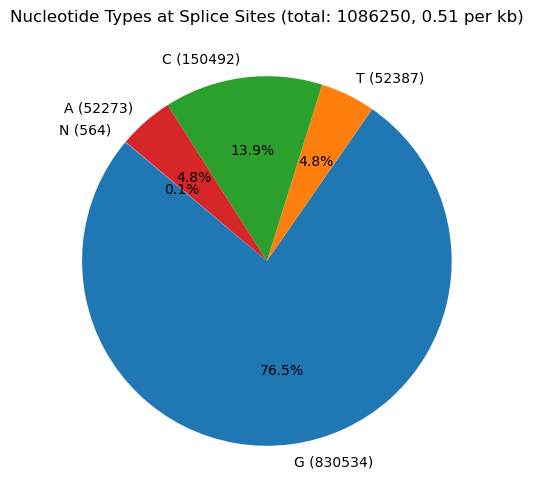

In [17]:
# only read if not already loaded
if 'rnasites_df' not in locals():
    rnasites_df = pd.read_pickle(rnasites_path)
all_cls_sites = []
for cls_types in rnasites_df['acceptor']:
    all_cls_sites.extend(cls_types)
for cls_types in rnasites_df['donor']:
    all_cls_sites.extend(cls_types)    
    
import matplotlib.pyplot as plt
from collections import Counter
cls_site_counts = Counter(all_cls_sites)
plt.figure(figsize=(6,6))
# label each pie with its count
labels = [f"{key} ({value})" for key, value in cls_site_counts.items()]
plt.pie(cls_site_counts.values(), labels=labels, autopct='%1.1f%%', startangle=140)
plt.gca().set_aspect("equal")

total_gene_length = rnasites_df['len'].sum()
plt.title(f"Nucleotide Types at Splice Sites (total: {len(all_cls_sites)}, {len(all_cls_sites)/total_gene_length*1000:.2f} per kb)")

plt.show()


In [7]:
from src import splice_feats

if 'genesites_heart' not in locals():
    genesites_heart = pd.read_pickle('data/pangolin_reproduced/genesites_heart.pkl')
print(f"Loaded genesites_heart with {len(genesites_heart)} entries from data/pangolin_reproduced/genesites_heart.pkl")

genesites_heart.iloc[0]

Loaded genesites_heart with 37632 entries from data/pangolin_reproduced/genesites_heart.pkl


gene_id                                               ENSG00000000003.17
chrom                                                               chrX
strand                                                                 -
gene_seq               TACCTTGTATTAGGTATTTATTTCCACAAAAGTTTGATGCTTACAA...
gene_start                                                      99882105
gene_end                                                        99894988
cls_mask_per_sample    [[False, False, False, False, False, False, Fa...
cls_sample_count       [2, 1, 33, 33, 33, 33, 33, 1, 1, 1, 1, 1, 33, ...
cls_mask               [True, True, True, True, True, True, True, Tru...
psi_mask_per_sample    [[True, True, True, True, True, True, True, Tr...
psi_sample_count       [30, 33, 33, 32, 29, 29, 27, 27, 27, 27, 27, 2...
psi_mask               [True, True, True, True, True, True, True, Tru...
cls_site               [99884797, 99884975, 99884984, 99885755, 99885...
cls_type               [acceptor, donor, donor, acc

In [ ]:

# use pytables to save train_feats which is a list of dictionaries
# Note: this appears to be quite slow as pytables is optimized for column access.
# May consider:
# 1) use one dataset for each sample and field as done by Pangolin
# 2) use h5py earray to store arrays

import tables
crop_size = 5000
flank_size = 5000
class CropFeat(tables.IsDescription):
    gene_id = tables.StringCol(100)  # adjust size as needed
    chrom = tables.StringCol(40)  # adjust size as needed
    strand = tables.StringCol(1)  # adjust size as needed
    gene_start = tables.Int32Col(1)
    gene_end = tables.Int32Col(1)
    crop_start = tables.Int32Col(1)
    crop_end = tables.Int32Col(1)
    seq = tables.StringCol(crop_size + 2 * flank_size)  # adjust size as needed
    seq_onehot = tables.UInt8Col(shape=(4, crop_size + 2 * flank_size))  # 4 channels for A,C,G,T
    cls = tables.Int8Col(crop_size)  # adjust size as needed
    cls_odds = tables.Float32Col(crop_size)  # adjust size as needed
    cls_mask = tables.Int8Col(crop_size)  # adjust size as needed
    psi = tables.Float32Col(crop_size)  # adjust size as needed
    psi_std = tables.Float32Col(crop_size)  # adjust size as needed
    psi_mask = tables.Int8Col(crop_size)  # adjust size as needed
    # add other fields as needed

h5file_path = 'data/gwsplice_genecrops.h5'
with tables.open_file(h5file_path, mode='w', title='Crop Features') as h5file:
    table = h5file.create_table('/', 'crop_feats', CropFeat, "Crop Features", expectedrows=1000000)
    feat_table_row = table.row
    # print(table.colnames)
    # print(table.coldescrs)
    # iterate over the rows of genesites_df
    i = 0
    for index, seq_sites in tqdm(genesites_df.iterrows(), total=len(genesites_df)):
        seq_feat = splice_feats.sprinkle_sites_on_sequence(seq_sites, debug=False)
        crop_feats = splice_feats.get_crop_feats_from_single_seq(seq_feat, crop_size=5000, flank_size=5000, min_sites=0, min_usage=0)

        for crop_feat in crop_feats:
            feat_table_row['gene_id'] = seq_sites['gene_id']
            feat_table_row['chrom'] = seq_sites['chrom']
            feat_table_row['strand'] = seq_sites['strand']
            feat_table_row['gene_start'] = seq_sites['gene_start']
            feat_table_row['gene_end'] = seq_sites['gene_end']
            feat_table_row['crop_start'] = crop_feat['crop_start']
            feat_table_row['crop_end'] = crop_feat['crop_end']
            feat_table_row['seq'] = crop_feat['seq']
            feat_table_row['seq_onehot'] = crop_feat['seq_onehot']
            feat_table_row['cls'] = crop_feat['cls']
            feat_table_row['cls_odds'] = crop_feat['cls_odds']
            feat_table_row['cls_mask'] = crop_feat['cls_mask']
            feat_table_row['psi'] = crop_feat['psi']
            feat_table_row['psi_std'] = crop_feat['psi_std']
            feat_table_row['psi_mask'] = crop_feat['psi_mask']
            # train_feat_row['gene_id'] = feat['gene_id']
            # train_feat_row['chrom'] = feat['chrom']
            # train_feat_row['strand'] = feat['strand']
            # train_feat_row['gene_start'] = feat['gene_start']
            # train_feat_row['gene_end'] = feat['gene_end']
            # add other fields as needed

            feat_table_row.append()

        # i += 1
        # if i > 1000:
        #     break
        
    table.flush()

Loaded seq_sites_df with 37632 entries from data/gwsplice_gene_sites.pkl


100%|██████████| 37632/37632 [1:15:01<00:00,  8.36it/s]  


In [31]:
import tables
with tables.open_file('data/gwsplice_genecrops.h5', mode='r') as h5file:
    table = h5file.root.crop_feats
    print(f"Total crop features stored: {table.nrows}")
    first_row = table[0]
    print(first_row['gene_id'])
    # get each row as a dictionary
    first_row_dict = {col: first_row[col] for col in table.colnames}
    print("First row:")
    for col in table.colnames:
        print(f"{col}: {first_row[col]}")

Total crop features stored: 447048
b'ENSG00000000003.17'
First row:
chrom: b'chrX'
cls: [0 0 0 ... 0 0 0]
cls_mask: [0 0 0 ... 0 0 0]
cls_odds: [0. 0. 0. ... 0. 0. 0.]
crop_end: [5000]
crop_start: [0]
gene_end: [99894988]
gene_id: b'ENSG00000000003.17'
gene_start: [99882105]
psi: [0. 0. 0. ... 0. 0. 0.]
psi_mask: [0 0 0 ... 0 0 0]
psi_std: [0. 0. 0. ... 0. 0. 0.]
seq: b'NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN

In [ ]:
from AmbiSplice import datasets
genecrops_set = datasets.GeneCropsDataset('data/gwsplice_genecrops.h5')
sampled_indices = np.random.choice(len(genecrops_set), size=10000, replace=False)
genecrops_samples = [genecrops_set[i] for i in sampled_indices]

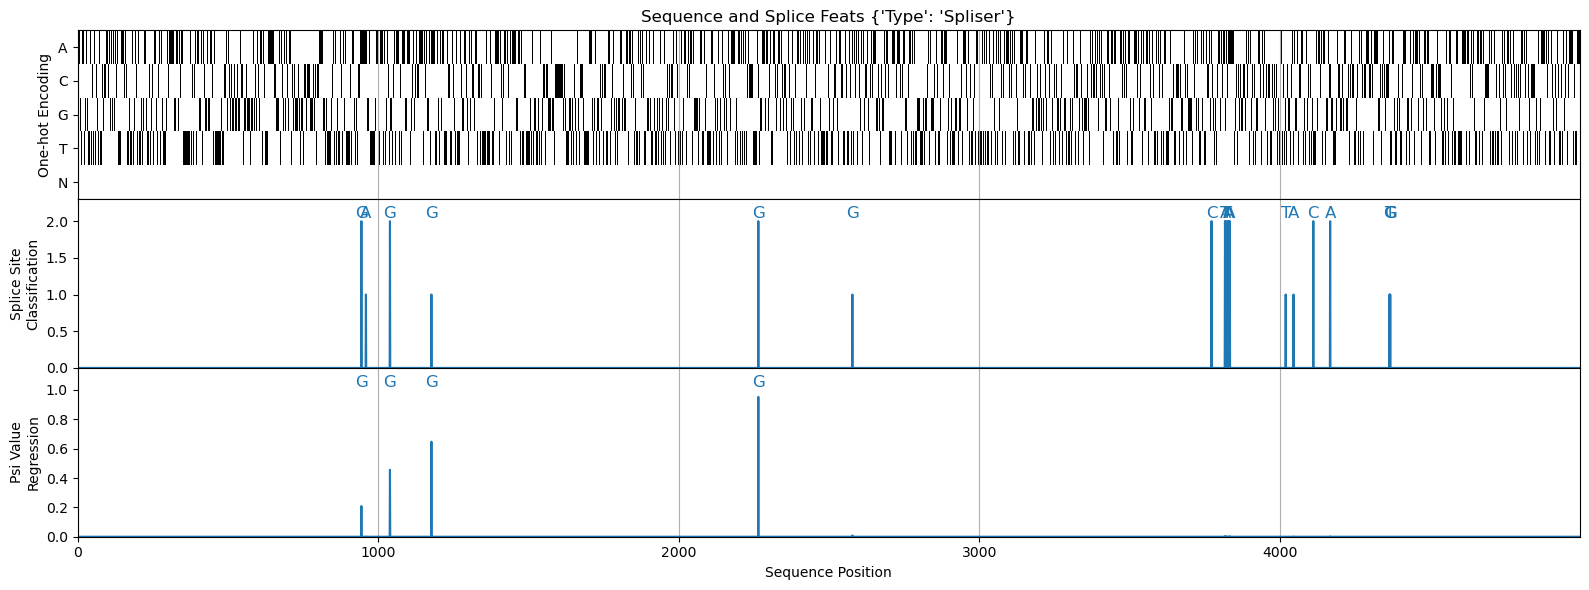

In [45]:
from AmbiSplice import visuals
import importlib
importlib.reload(visuals)
for sample_feat in genecrops_samples:
    if sample_feat['cls'].sum() < 7 or sample_feat['psi'].sum() <= 0.1:
        continue
    visuals.plot_train_feats(sample_feat, meta_dict={'Type': 'Spliser'})
    break
# visuals.plot_train_feats(genecrops_samples[0], meta_dict={'Type': 'Spliser'})

# train_feat = genesites_df.iloc[10]
# fig, ax1 = plt.subplots(figsize=(20, 4))

# ax1.plot(train_feat['cls'], drawstyle='steps-mid')
# # ax1.set_title(f"Gene: {gene_sites['gene_id']}, Strand: {gene_sites['strand']}, Chrom: {gene_sites['chrom']}, Length: {len(rna_seq)}")
# ax1.set_title(f"Gene crop: start {train_feat['start']}, end {train_feat['end']}, Seq length: {len(train_feat['seq'])},"
#               f" Num sites: {np.sum(train_feat['cls']>0)}, Total PSI: {np.nansum(train_feat['psi']):.2f}")
# ax1.set_xlabel("Position in gene sequence")
# ax1.set_ylabel("Splice site classification label")
# ax1.set_yticks([0, 1, 2, 3])
# ax1.set_yticklabels(['No site', 'Donor', 'Acceptor', 'Hybrid'])
# ax1.grid()

# ax2 = ax1.twinx()
# ax2.plot(train_feat['psi'], drawstyle='steps', marker='o', markersize=4, color='orange')
# ax2.set_ylabel("PSI value")
# plt.xlabel("Position in gene sequence")
# plt.ylabel("PSI value")
# plt.grid()
# plt.show()

## Pangolin Reproduced vs Original datasets

In [ ]:
from src import datasets
genecrops_set = datasets.GeneCropsDataset('data/pangolin_reproduced/gwsplice_genecrops.h5')
# sampled_indices = np.random.choice(len(genecrops_set), size=10000, replace=False)
# genecrops_samples = [genecrops_set[i] for i in sampled_indices]
fasta_file = 'data/gwsplice_genecrops.fasta'
with open(fasta_file, 'w') as hfile:
    for i in range(len(genecrops_set)):
        crop_feat = genecrops_set[i]
        seq = crop_feat['seq']
        if len(seq) == 15000:
            seq = seq[5000:10000].decode()  # extract the central 5kb crop
        elif len(seq) == 5000:
            seq = seq.decode()
        else:
            raise ValueError(f"Unexpected sequence length: {len(seq)}")
        gene_id = crop_feat['gene_id']
        crop_start = crop_feat['start']
        crop_end = crop_feat['end']
        hfile.write(f">idx:{i};{gene_id}:{crop_start}-{crop_end}\n")
        hfile.write(f"{seq}\n")
print(f"Saved genecrops sequences to {fasta_file}")

Saved genecrops sequences to data/gwsplice_genecrops.fasta


In [12]:
import os
import mappy

mmi_file = 'data/gwsplice_genecrops.mmi'
# check if mmi_file is newer than fasta_file
if os.path.exists(mmi_file) and os.path.getmtime(mmi_file) >= os.path.getmtime(fasta_file):
    print(f"Using existing mmi index file: {mmi_file}")
    aligner = mappy.Aligner(mmi_file, preset='asm5')
else:
    aligner = mappy.Aligner(fasta_file, preset='asm5', fn_idx_out=mmi_file)

if not aligner:
    raise Exception("Failed to load/build index for genecrops sequences.")
print("Aligner built/loaded successfully for genecrops sequences.")

Using existing mmi index file: data/gwsplice_genecrops.mmi
Aligner built/loaded successfully for genecrops sequences.


In [ ]:
from src import datasets
pangolin_set = datasets.PangolinDataset(file_path='data/pangolin/dataset_train_all.h5')
print(len(pangolin_set))

231460


In [47]:
min_identity = 0.98
min_coverage = 0.98
import numpy as np
for i in np.random.randint(0, len(pangolin_set), size=1000):
    pangolin_feats = pangolin_set[i]
    seq = pangolin_feats['seq']
    if len(seq) == 15000:
        seq = seq[5000:10000] # extract the central 5kb crop
    elif len(seq) == 5000:
        seq = seq
    else:
        raise ValueError(f"Unexpected sequence length: {len(seq)}")    
        
    is_paralog = False
    for hit in aligner.map(seq):
        identity = hit.mlen / hit.blen
        coverage = hit.blen / len(seq)
        if identity >= min_identity and coverage >= min_coverage:
            is_paralog = True
            print(f"Sample {i} aligned to reference:")
            print(f"  Reference name: {hit.ctg}")
            print(f"  Alignment identity: {identity:.4f}")
            print(f"  Alignment coverage: {coverage:.4f}")
            print(hit)
            break
    if is_paralog:
        break
    else:
        print(f"Sample {i} did not align to reference with identity >= {min_identity} and coverage >= {min_coverage}.")

Sample 30982 aligned to reference:
  Reference name: idx:154817;ENSG00000155085.16:15000-20000
  Alignment identity: 1.0000
  Alignment coverage: 1.0000
0	5000	+	idx:154817;ENSG00000155085.16:15000-20000	5000	0	5000	5000	5000	60	tp:A:P	ts:A:.	cg:Z:5000M


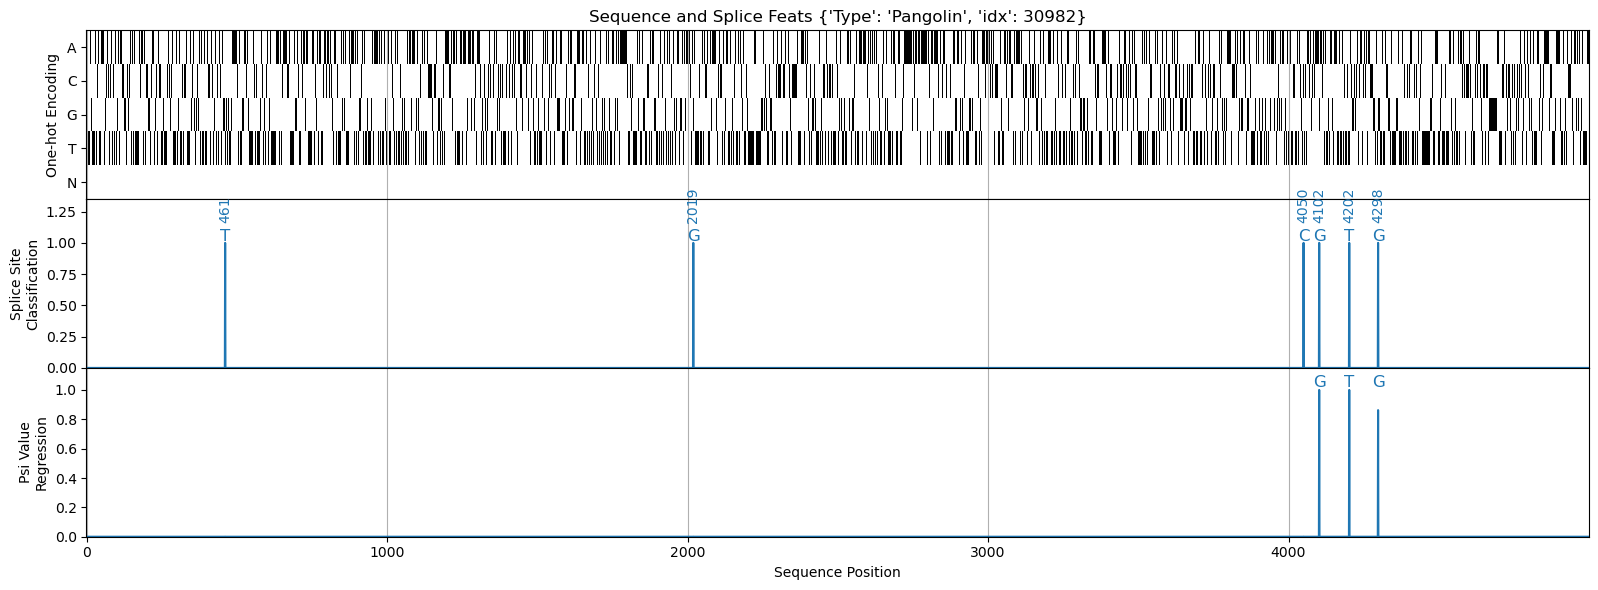

In [66]:
from AmbiSplice import visuals
import importlib
importlib.reload(visuals)
from AmbiSplice import utils
# utils.peekaboo_tensors(pangolin_feats, prefix="pangolin_feats")
visuals.plot_train_feats(pangolin_feats, meta_dict={'Type': 'Pangolin', 'idx': i})

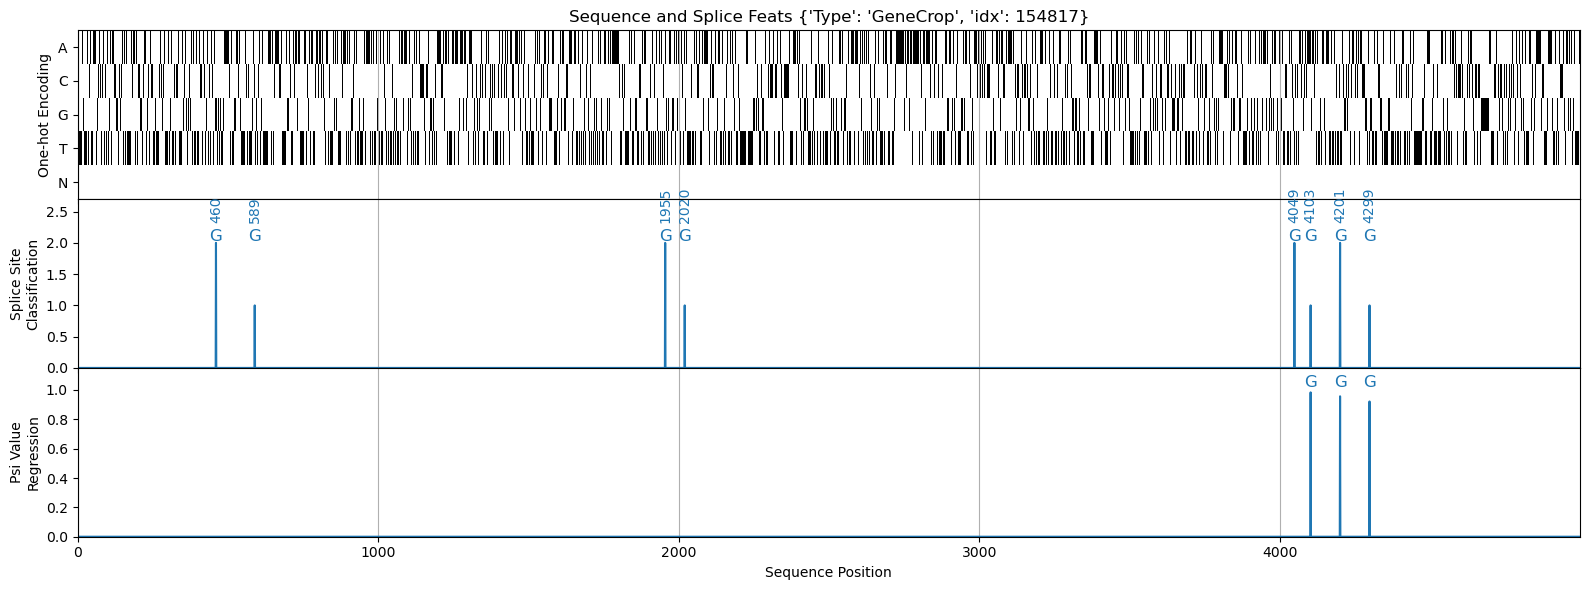

In [67]:
idx = int(hit.ctg.split(';')[0].split(':')[1])
genecrop_feats = genecrops_set[idx]
# utils.peekaboo_tensors(genecrop_feats, prefix="genecrop_feats")
visuals.plot_train_feats(genecrop_feats, meta_dict={'Type': 'GeneCrop', 'idx': idx})

## Pangolin dataset

In [ ]:
# read in h5 file: /home/xqiu/github/Pangolin_train/preprocessing/datafile_Human_1_train_all.h5
import h5py
h5_path = '/home/xqiu/github/Pangolin_train/preprocessing/datafile_Human_1_train_all.h5'
h5f = h5py.File(h5_path, 'r')
print("Keys: ", list(h5f.keys()))
print(len(h5f['CHROM']))  # number of samples
print(h5f['CHROM'][0:10])  # first 10 chromosome names
print(h5f['STRAND'][0:10])  # first 10 strand information
print(h5f['NAME'][0:10])  # first 10 gene names
print(h5f['PARALOG'][0:10])  # first 10 paralog information
print(h5f['SEQ'][0])  # first sequence
print(h5f['JN_START'][0])  # first junction start positions
print(h5f['TX_END'][0])  # first junction end positions
print(h5f['TX_START'][0])  # first junction start positions
seq_len = len(h5f['SEQ'][0])  # length of the sequence
print(f"Sequence length: {seq_len}")

Keys:  ['CHROM', 'JN_START', 'NAME', 'PARALOG', 'SEQ', 'STRAND', 'TX_END', 'TX_START']


In [ ]:
from AmbiSplice import datasets
pangolin_set = datasets.PangolinDataset(file_path='data/pangolin/dataset_train_all.h5')
print(len(pangolin_set))

231460


In [ ]:
sampled_indices = np.random.choice(len(pangolin_set), size=10000, replace=False)
train_samples = [pangolin_set[i] for i in sampled_indices]

In [3]:
import mitas_utils
import importlib
importlib.reload(mitas_utils)
import numpy as np
cls_mat = np.concatenate([sample_feat['cls'] for sample_feat in train_samples], axis=1)
cls_counts = cls_mat.sum(axis=1)

psi_mat = np.concatenate([sample_feat['psi'] for sample_feat in train_samples], axis=1)
psi_counts = (psi_mat > 0).sum(axis=1)

# calculate the pfarm metrics for every pair along the first dimension
metrics_mat = np.zeros((cls_mat.shape[0], cls_mat.shape[0], 6))  # precision, f1, acc, recall, mcc, psi_rmse
for i in range(cls_mat.shape[0]):
    for j in range(cls_mat.shape[0]):
        pfarm_metrics = mitas_utils.pfarm_metric(cls_mat[i], cls_mat[j], keep_batchdim=False)
        metrics_mat[i, j, :5] = pfarm_metrics
        metrics_mat[i, j, 5] = np.sqrt(np.std((psi_mat[i] - psi_mat[j]) * ( psi_mat[i] > 0) * ( psi_mat[j] > 0)))

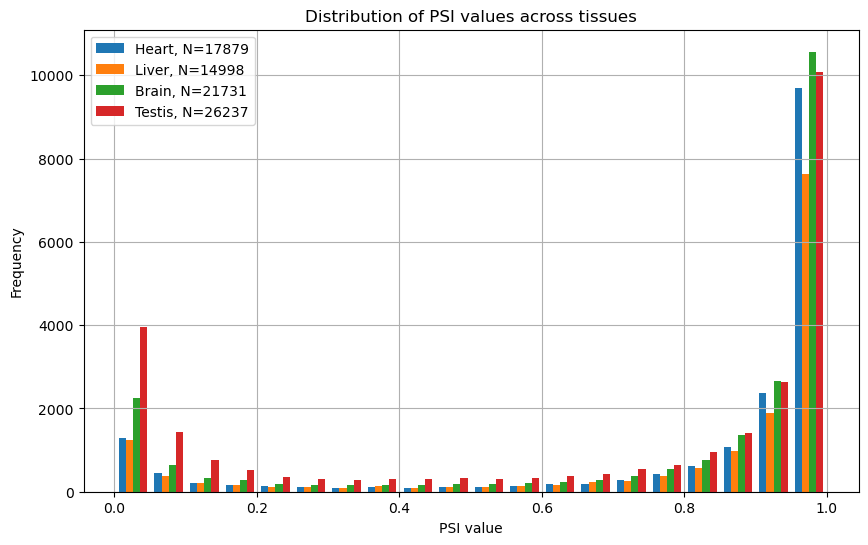

In [11]:
psi_labels = [f'{tissue}, N={psi_counts[i]}' for i, tissue in enumerate(['Heart', 'Liver', 'Brain', 'Testis'])]

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
labels = ['Heart', 'Liver', 'Brain', 'Testis']
data_to_plot = [psi_mat[i, psi_mat[i]>0] for i in range(psi_mat.shape[0])]
plt.hist(data_to_plot, bins=20, label=psi_labels)

plt.title("Distribution of PSI values across tissues")
plt.xlabel("PSI value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

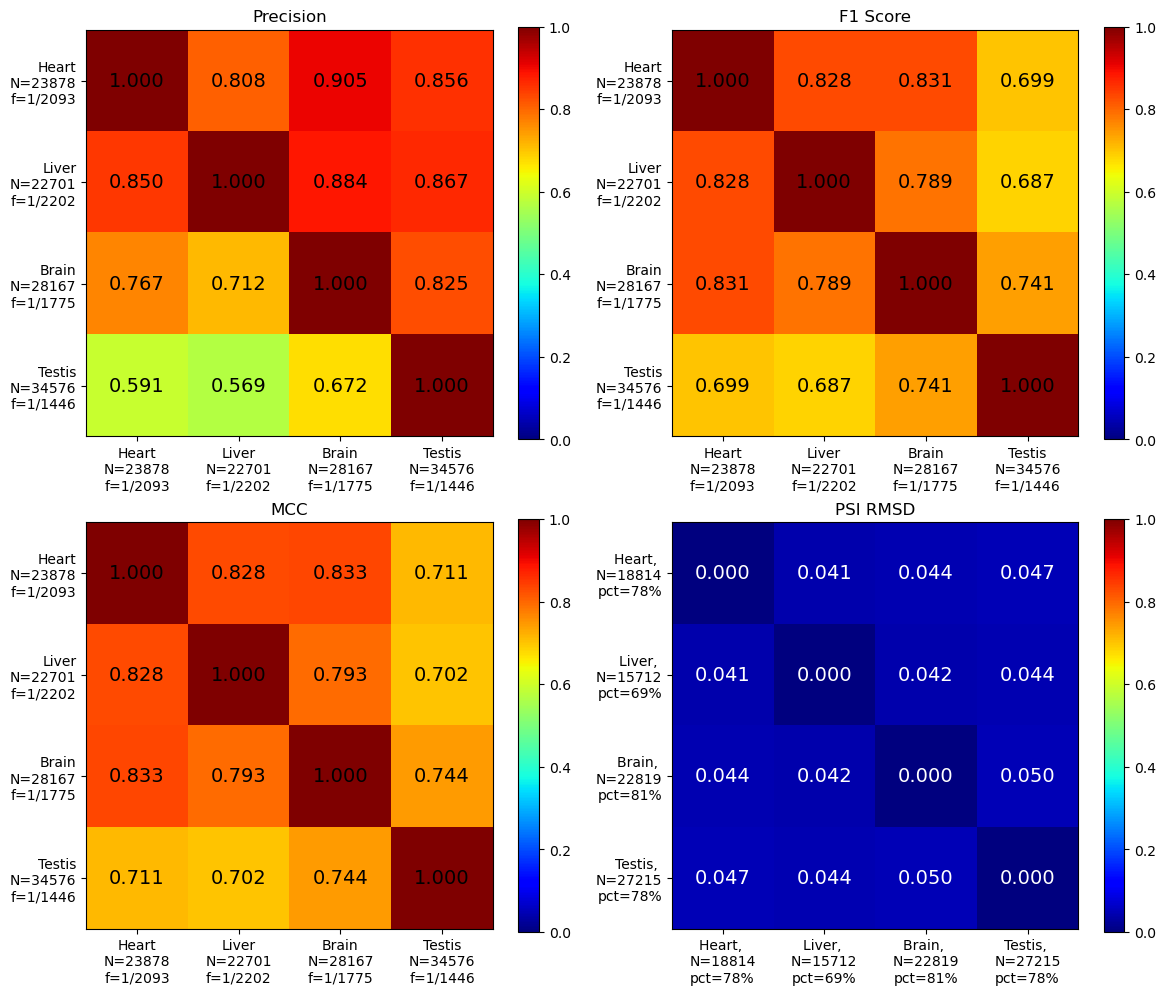

In [ ]:
cls_labels = [f'{tissue}\nN={cls_counts[i]}\nf=1/{int(cls_mat.shape[1]/cls_counts[i])}' for i, tissue in enumerate(['Heart', 'Liver', 'Brain', 'Testis'])]
psi_labels = [f'{tissue}, \nN={psi_counts[i]}\npct={int(psi_counts[i]/cls_counts[i]*100)}%' for i, tissue in enumerate(['Heart', 'Liver', 'Brain', 'Testis'])]

# Visualize precision, f1, acc, recall in a separate heatmap in a 2x2 subplot
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
metrics_names = ['Precision', 'F1 Score', 'Accuracy', 'Recall', 'MCC', 'PSI RMSD']
for i, imetric in enumerate([0, 1, 4, 5]):
    ax = axs[i // 2, i % 2]
    im = ax.imshow(metrics_mat[:, :, imetric], cmap='jet', vmin=0, vmax=1)
    # show the values at the center of each pixel
    for i in range(metrics_mat.shape[0]):
        for j in range(metrics_mat.shape[1]):
            text = ax.text(j, i, f"{metrics_mat[i, j, imetric]:.3f}", size=14,
                           ha="center", va="center", color="w" if metrics_mat[i, j, imetric] < 0.5 else "black")
    ax.set_title(metrics_names[imetric])
    fig.colorbar(im, ax=ax)
    ax.set_xticks(np.arange(len(cls_labels)))
    ax.set_yticks(np.arange(len(cls_labels)))
    if imetric == 5:
        ax.set_xticklabels(psi_labels)
        ax.set_yticklabels(psi_labels)
    else:
        ax.set_xticklabels(cls_labels)
        ax.set_yticklabels(cls_labels)
plt.tight_layout()
plt.show()

# fig.savefig('pangolin_train_cross_tissue_metrics_heatmap.png', dpi=300)


pangolin_feats Variables:
Key                     Type                 Shape                     Dtype           Device          Requires Grad  
--------------------------------------------------------------------------------------------------------------
seq                     str                  -                         -               -               -              
seq_onehot              ndarray              (4, 15000)                float32         -               -              
cls                     ndarray              (4, 5000)                 int64           -               -              
psi                     ndarray              (4, 5000)                 float32         -               -              
chrom                   str                  -                         -               -               -              
start                   int                  -                         -               -               -              
end                     int  

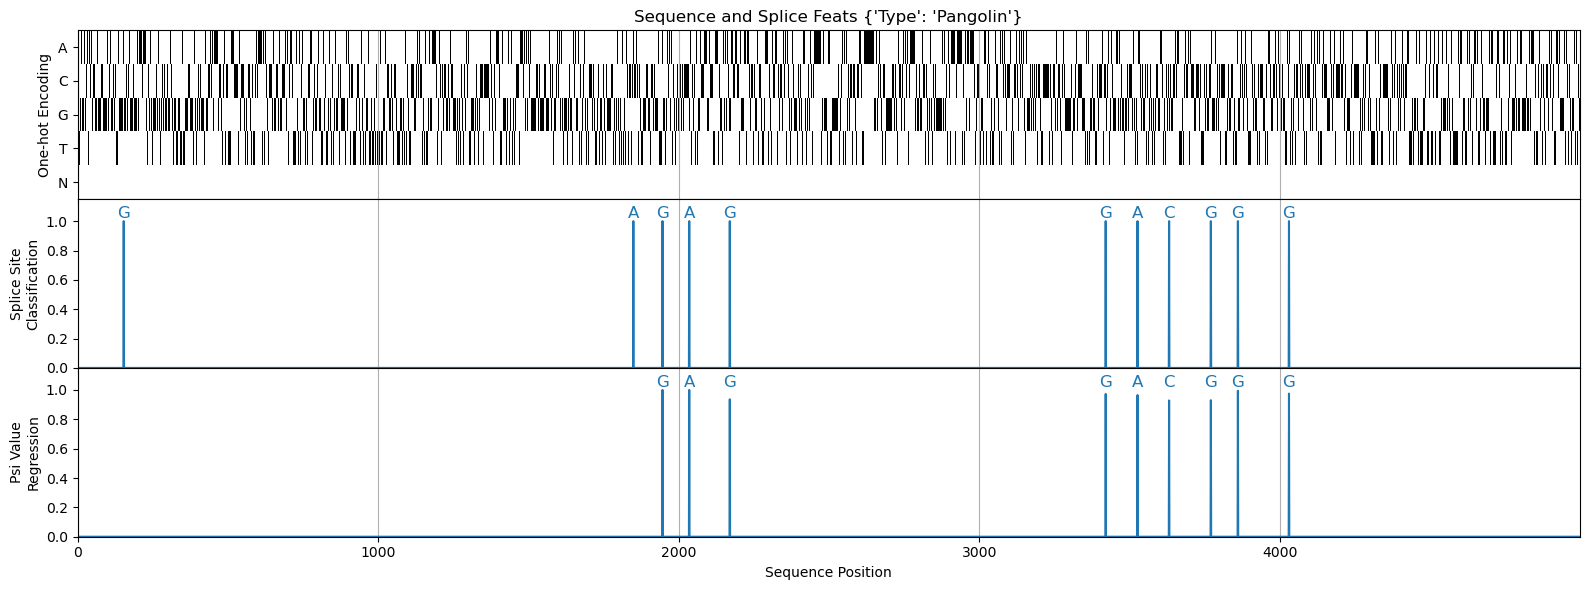

In [29]:
from AmbiSplice import visuals
import importlib
importlib.reload(visuals)
from AmbiSplice import utils

for pangolin_feats in train_samples:
    if pangolin_feats['cls'].sum() < 40 or pangolin_feats['psi'].sum() <= 0.1:
        continue
    utils.peekaboo_tensors(pangolin_feats, prefix="pangolin_feats")
    visuals.plot_train_feats(pangolin_feats, meta_dict={'Type': 'Pangolin'})
    break

In [11]:
# from all train_samples, collect the nucleotides that are labelled as splice sites
splice_sites = []
for pangolin_feats in train_samples:
    seq = np.array(list(pangolin_feats['seq'][5000:10000]), dtype='<U1')
    splice_sites.extend(seq[pangolin_feats['cls'][0] > 0])

In [12]:
# count the occurrences of each nucleotide
from collections import Counter
nuc_counts = Counter(splice_sites)
print("Nucleotide counts at splice sites:")
for nuc, count in nuc_counts.items():
    print(f"{nuc}: {count}")

Nucleotide counts at splice sites:
G: 14826
C: 1928
A: 4069
T: 2102


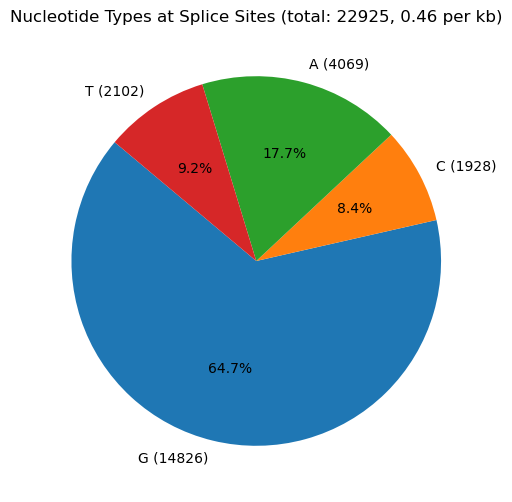

In [20]:
# plot the nucleotide distribution as a pie chart
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
labels = [f"{key} ({value})" for key, value in nuc_counts.items()]
plt.pie(nuc_counts.values(), labels=labels, autopct='%1.1f%%', startangle=140)
total_gene_length = len(train_samples) * 5000  # each sample has 5000 positions
plt.title(f"Nucleotide Types at Splice Sites (total: {sum(nuc_counts.values())}, "
          f"{sum(nuc_counts.values())/total_gene_length*1000:.2f} per kb)")
plt.show()

## Gene expression data from Pangolin samples

In [1]:
import os
import pandas as pd
cpm_path = os.path.join('data/gwsplice/E-MTAB-6814', 'Human.CPM.txt')
cpm_df = pd.read_csv(cpm_path, sep=' ', index_col=0)
print(cpm_df.shape)

(51299, 297)


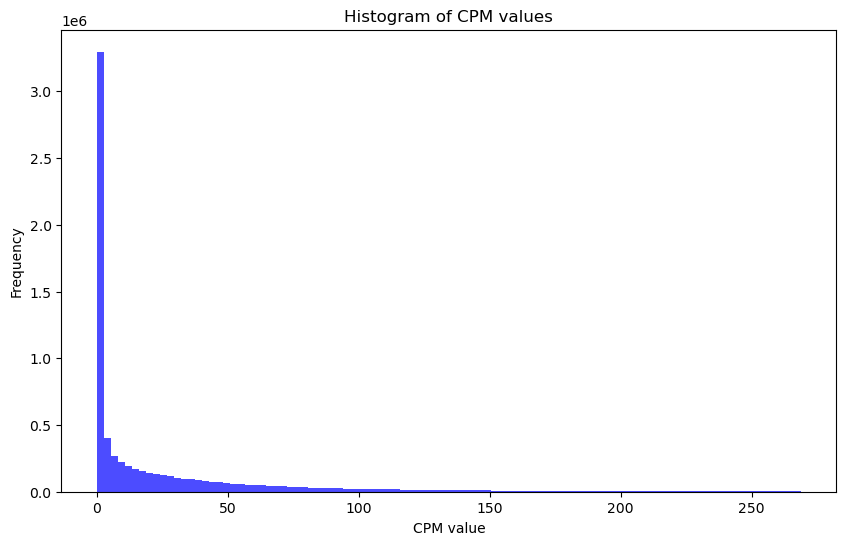

In [3]:
import matplotlib.pyplot as plt
all_values = cpm_df.values.flatten()
plt.figure(figsize=(10,6))
plt.hist(all_values, bins=100, color='blue', alpha=0.7, range=(0.001, np.percentile(all_values, 99)))
plt.title('Histogram of CPM values')
plt.xlabel('CPM value')
plt.ylabel('Frequency')
plt.show()

After low-expression filter: (18513, 297) genes remain out of 51299


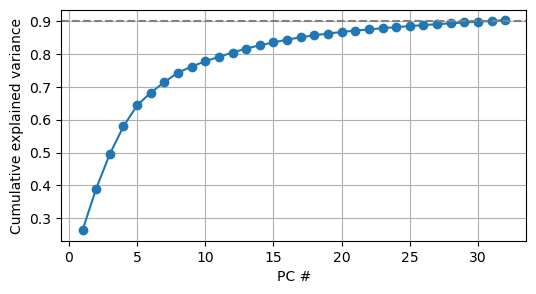

Saved sample PCA embeddings: (297, 32)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# PCA on genes (rows = genes, cols = samples)
import matplotlib.pyplot as plt

# params
min_cpm = 1.0
min_frac = 0.10
top_n_genes = 5000      # restrict to most variable genes (adjust)
n_components = 32       # number of PCs to keep

# 1) filter low-expression genes
mask = (cpm_df > min_cpm).sum(axis=1) >= (min_frac * cpm_df.shape[1])
filtered = cpm_df.loc[mask]
print("After low-expression filter:", filtered.shape, "genes remain out of", cpm_df.shape[0])

# 2) select top variable genes (by variance across samples)
var = filtered.var(axis=1)
# divide the var by the mean to get a more balanced selection (which however could be the noisiest)
var = var / (filtered.mean(axis=1) ** 2)
selected_genes = var.nlargest(min(top_n_genes, len(var))).index
expr_sel = filtered.loc[selected_genes]

# Switch to samples vs genes matrix for PCA
expr_sel = expr_sel.T  # shape (n_samples, n_genes)

# 3) transform (log1p) and scale
scaler = StandardScaler()
sam_vs_gene_normalized = scaler.fit_transform(np.log1p(expr_sel.values))  # center/scale features (genes)

# 4) PCA
pca = PCA(n_components=min(n_components, sam_vs_gene_normalized.shape[1]), svd_solver='auto', random_state=0)
pcs = pca.fit_transform(sam_vs_gene_normalized)   # shape (n_samples, n_components)

# 5) inspect variance explained
explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)
plt.figure(figsize=(6,3))
plt.plot(np.arange(1, len(explained)+1), cum_explained, marker='o')
plt.xlabel('PC #'); plt.ylabel('Cumulative explained variance'); plt.grid(True)
plt.axhline(0.9, color='gray', linestyle='--')  # 90% line
plt.show()

# 6) save results
pcs_df = pd.DataFrame(pcs, index=expr_sel.index, columns=[f'PC{i+1}' for i in range(pcs.shape[1])])
pcs_df.to_csv("sample_pca_embeddings.csv")
print("Saved sample PCA embeddings:", pcs_df.shape)

# optional: save PCA loadings (how genes contribute to PCs)
loadings = pd.DataFrame(pca.components_.T, index=expr_sel.columns, columns=pcs_df.columns)
loadings.to_csv("gene_pca_loadings.csv")


Saved tissue-average PCA embeddings: (7, 32)


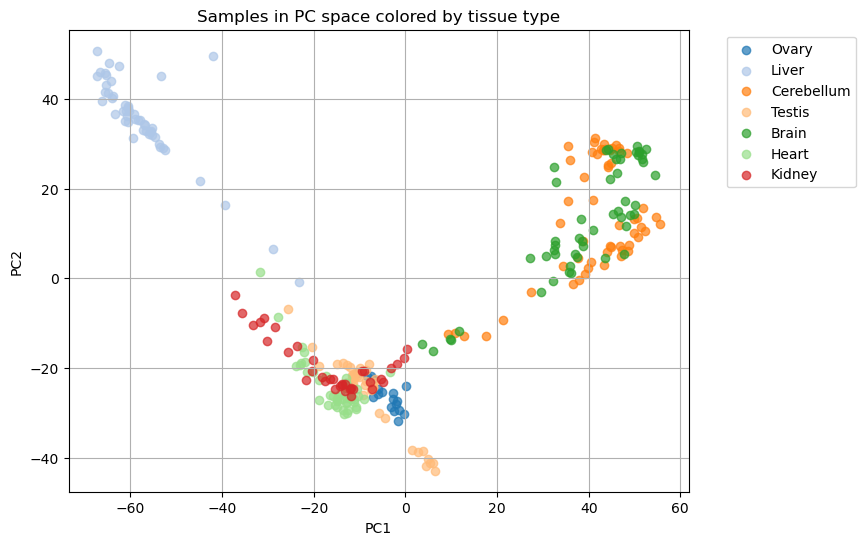

In [4]:
# average samples per tissue type and save
tissue_types = [_col.split('.')[0] for _col in cpm_df.columns]
tissue_type_set = list(set(tissue_types))
for i, tisue in enumerate(tissue_type_set):
    tissue_mask = [t == tisue for t in tissue_types]
    pcs_tissue = pcs_df.loc[tissue_mask]
    pcs_tissue_mean = pcs_tissue.mean(axis=0)
    pcs_tissue_mean.name = tisue
    if i == 0:
        pcs_avg_df = pd.DataFrame(pcs_tissue_mean).T
    else:
        pcs_avg_df = pd.concat([pcs_avg_df, pd.DataFrame(pcs_tissue_mean).T], axis=0)
# save average pcs per tissue
# convert all index to lowercase strings
pcs_avg_df.index = [str(idx).lower() for idx in pcs_avg_df.index]
pcs_avg_df.to_csv("tissue_avg_pca_embeddings.csv")
print("Saved tissue-average PCA embeddings:", pcs_avg_df.shape)

# visualize samples in PC space
import matplotlib.pyplot as plt
tissue_type_to_color = {tissue: plt.cm.tab20(i) for i, tissue in enumerate(tissue_type_set)}
plt.figure(figsize=(8,6))
for i, tissue in enumerate(tissue_type_set):
    tissue_mask = [t == tissue for t in tissue_types]
    plt.scatter(pcs_df.loc[tissue_mask, 'PC1'], pcs_df.loc[tissue_mask, 'PC2'],
                color=tissue_type_to_color[tissue], label=tissue, alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Samples in PC space colored by tissue type')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

(7, 32)
(32,)


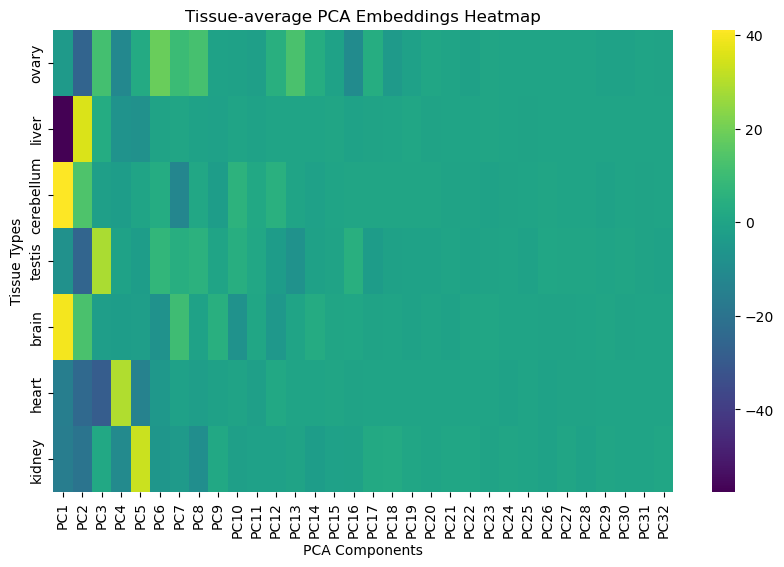

In [10]:
# read in the tissue-average PCA embeddings
tissue_pca_path = "tissue_avg_pca_embeddings.csv"
tissue_pca_df = pd.read_csv(tissue_pca_path, index_col=0)
print(tissue_pca_df.shape)
print(tissue_pca_df.loc['heart'].values.shape)
# visualize the tissue level embeddings as a heatmap
import seaborn as sns
plt.figure(figsize=(10,6))
sns.heatmap(tissue_pca_df, cmap='viridis')
plt.title('Tissue-average PCA Embeddings Heatmap')
plt.xlabel('PCA Components')
plt.ylabel('Tissue Types')
plt.show()


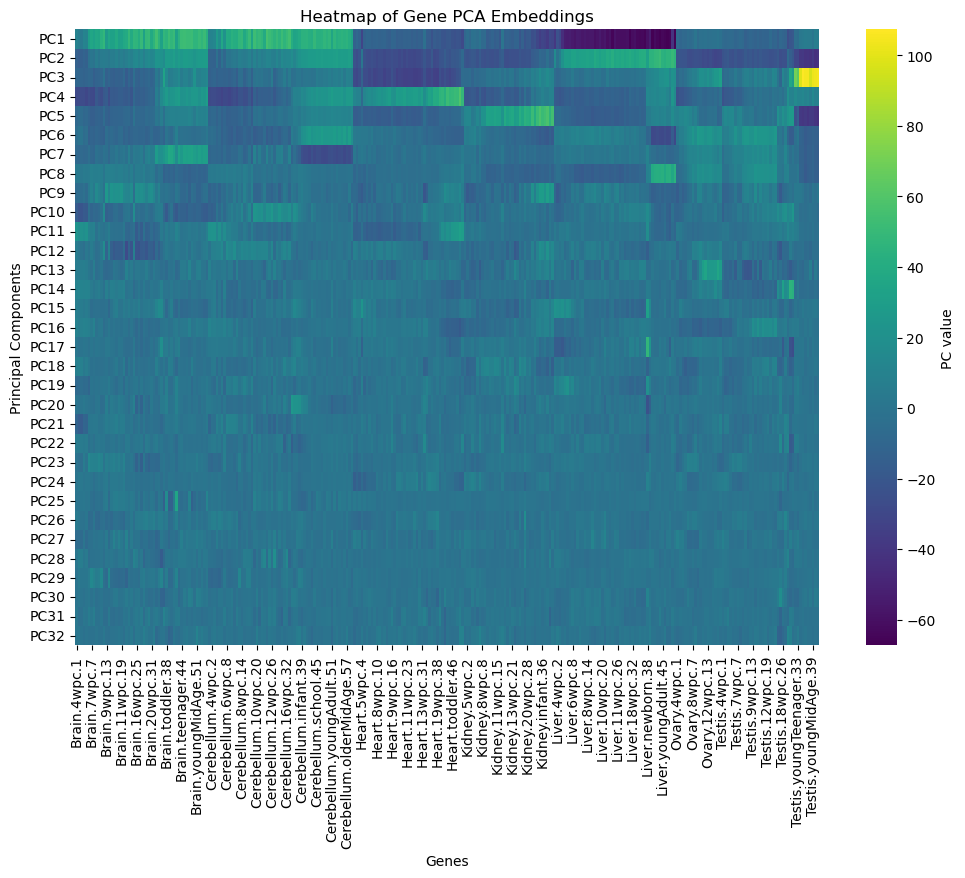

In [21]:
# visualize the 32 PCs using a heatmap
import seaborn as sns
plt.figure(figsize=(12,8))
sns.heatmap(pcs_df.T, cmap='viridis', cbar_kws={'label': 'PC value'})
plt.xlabel('Genes')
plt.ylabel('Principal Components')
plt.title('Heatmap of Gene PCA Embeddings')
plt.show()

In [4]:
from collections import Counter

tissue_types = [_col.split('.')[0] for _col in cpm_df.columns]
tissue_type_counts = Counter(tissue_types)
print("Tissue type counts:")
for tissue, count in tissue_type_counts.items():
    print(f"{tissue}: {count}")
# get unique tissue types
tissue_types = list(set(tissue_types))
print(f"Total tissue types: {len(tissue_types)}")
print(tissue_types)
# for each tissue type, get the average cpm across samples, as well as stddev and relative stddev
tissue_cpm_stats = {}
for tissue in tissue_types:
    tissue_cols = [col for col in cpm_df.columns if col.startswith(tissue + '.')]
    tissue_cpm = cpm_df[tissue_cols]
    tissue_mean = tissue_cpm.mean(axis=1)
    tissue_std = tissue_cpm.std(axis=1)
    tissue_cpm_stats[tissue] = {'mean': tissue_mean, 'std': tissue_std, 'relative_std': tissue_std / tissue_mean}
print(tissue_cpm_stats['Heart']['mean'].head())  # print first 5 genes' mean cpm in Heart

Tissue type counts:
Brain: 53
Cerebellum: 58
Heart: 44
Kidney: 36
Liver: 49
Ovary: 18
Testis: 39
Total tissue types: 7
['Kidney', 'Ovary', 'Liver', 'Heart', 'Brain', 'Testis', 'Cerebellum']
ENSG00000000003    43.649419
ENSG00000000005     2.540847
ENSG00000000419    38.926247
ENSG00000000457    17.692401
ENSG00000000460    11.962084
dtype: float64


In [20]:
# show the genes with lowest relative stddev in Heart tissue
heart_relative_std = tissue_cpm_stats['Heart']['relative_std']
lowest_std_genes = heart_relative_std.nsmallest(10)
print("Genes with lowest relative stddev in Heart tissue:")
print(lowest_std_genes)
# also show 10 largest relative stddev genes
largest_std_genes = heart_relative_std.nlargest(10)
print("Genes with largest relative stddev in Heart tissue:")
print(largest_std_genes)


Genes with lowest relative stddev in Heart tissue:
ENSG00000111361    0.122627
ENSG00000006194    0.125877
ENSG00000160679    0.129342
ENSG00000087206    0.132576
ENSG00000163161    0.133244
ENSG00000089053    0.137007
ENSG00000101150    0.138659
ENSG00000119321    0.139913
ENSG00000241258    0.144809
ENSG00000145191    0.145457
dtype: float64
Genes with largest relative stddev in Heart tissue:
ENSG00000200283    6.63325
ENSG00000215906    6.63325
ENSG00000203786    6.63325
ENSG00000214510    6.63325
ENSG00000240386    6.63325
ENSG00000250606    6.63325
ENSG00000253508    6.63325
ENSG00000253654    6.63325
ENSG00000270937    6.63325
ENSG00000273252    6.63325
dtype: float64


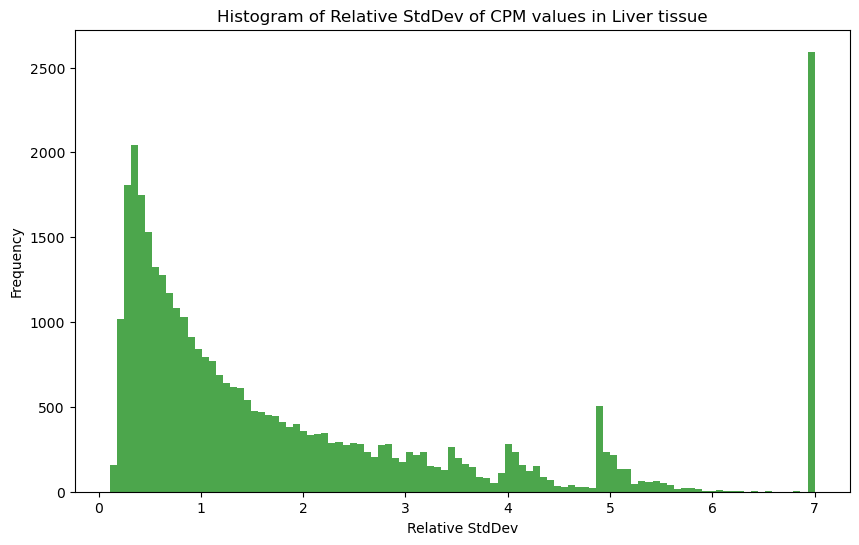

In [19]:
# show the distribution of relative stddev in Liver tissue
liver_relative_std = tissue_cpm_stats['Liver']['relative_std']
plt.figure(figsize=(10,6))
plt.hist(liver_relative_std.dropna(), bins=100, color='green', alpha=0.7)
plt.title('Histogram of Relative StdDev of CPM values in Liver tissue')
plt.xlabel('Relative StdDev')
plt.ylabel('Frequency')
plt.show()

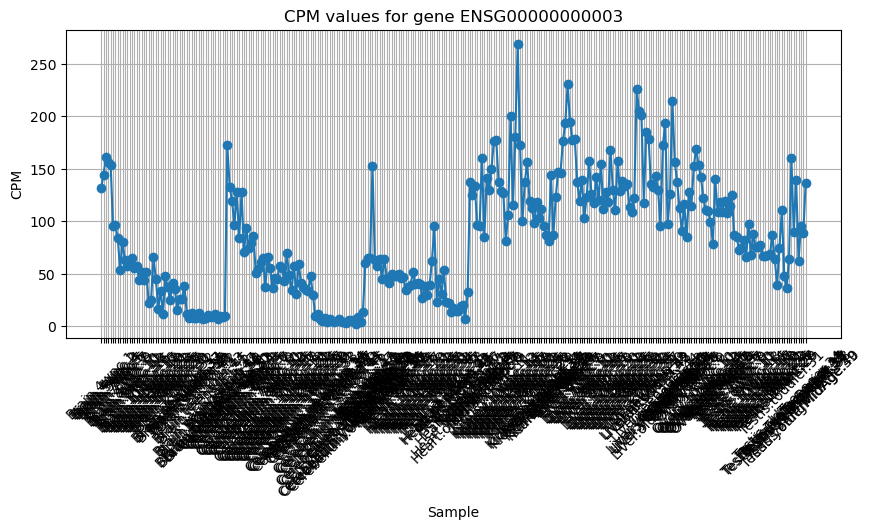

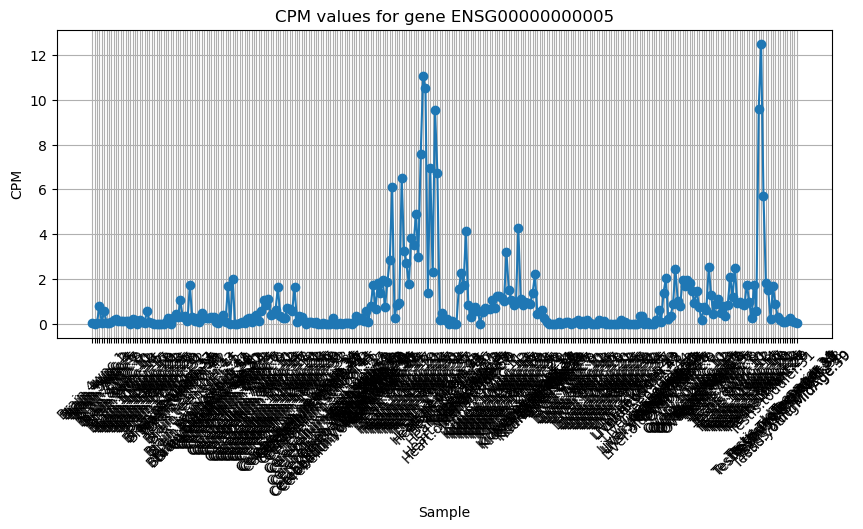

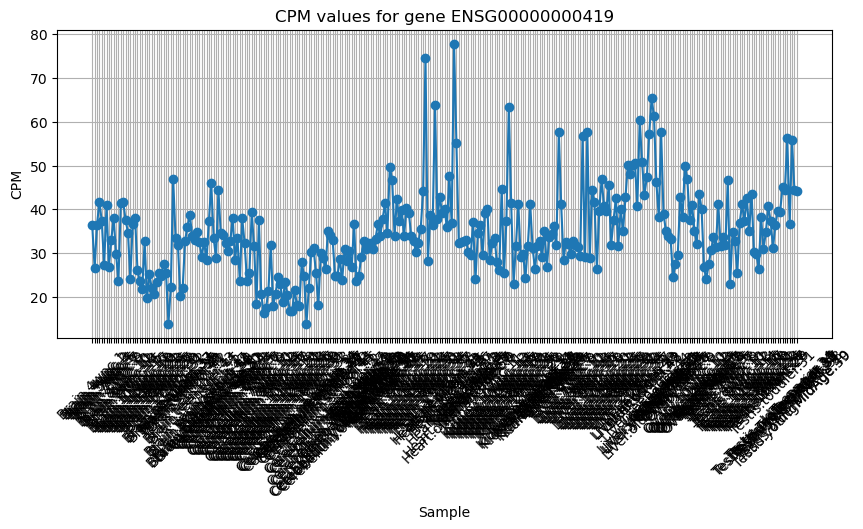

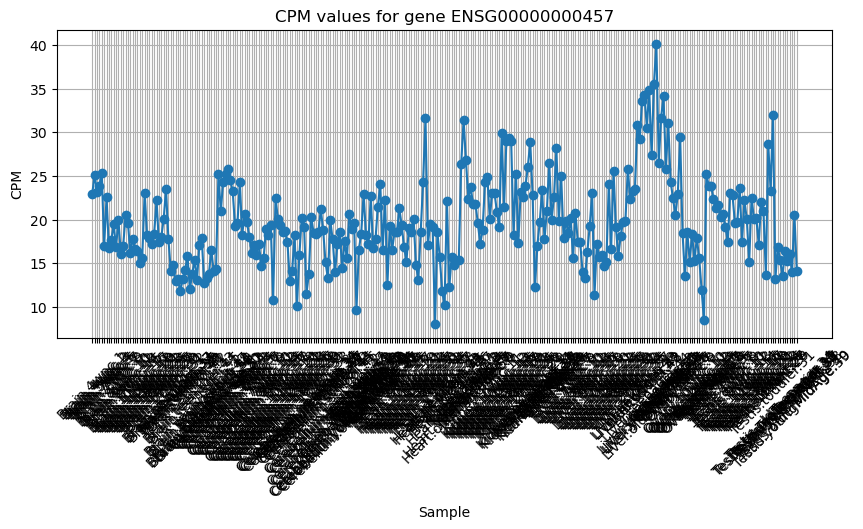

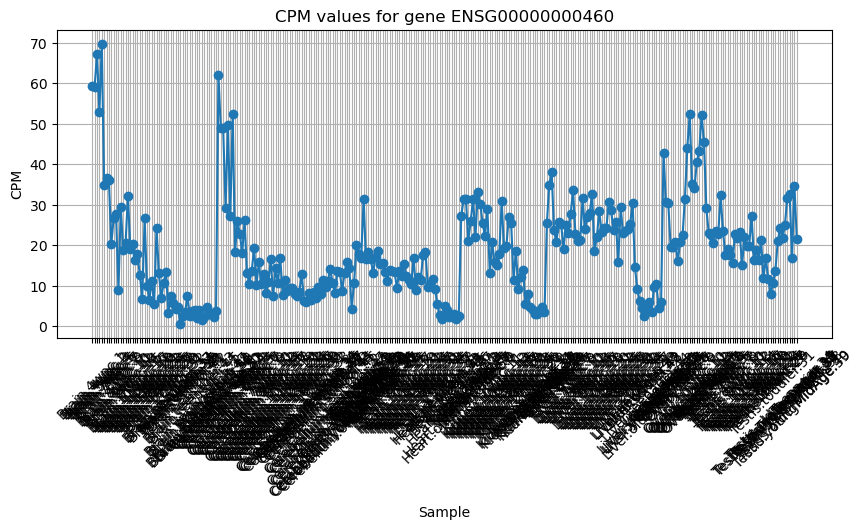

In [8]:
# visualize the CPM values for the first 5 genes
import matplotlib.pyplot as plt
for gene_id in cpm_df.index[:5]:
    plt.figure(figsize=(10, 4))
    plt.plot(cpm_df.columns, cpm_df.loc[gene_id], marker='o')
    plt.title(f"CPM values for gene {gene_id}")
    plt.xlabel("Sample")
    plt.ylabel("CPM")
    plt.xticks(rotation=45)
    plt.grid()
    plt.show()

# MAJIQ analysis on Pangolin samples

In [ ]:

tsv_file = os.path.join(os.getcwd(), "data/Human/E-MTAB-6814/majiq_heart_psi.tsv")

majiq_df = pd.read_csv(tsv_file, sep='\t', comment='#')
# print(majiq_df.head())

sj_columns = ["seqid", "strand", "gene_name", "gene_id", "event_type", 
              "ref_exon_start", "ref_exon_end", "start", "end", "is_intron", 
              "other_exon_start", "other_exon_end", 
              "is_denovo", "ref_exon_denovo", "other_exon_denovo", "event_denovo",]

for col in sj_columns:
    if col not in majiq_df.columns:
        raise ValueError(f"Column {col} not found in MAJIQ dataframe")
else:
    print(f"All columns are present, hooray!")
    
sam_columns = [col for col in majiq_df.columns if col not in sj_columns]
print(f"Found {len(sam_columns)} sample columns.")
assert len(sam_columns) % 4 == 0, "Number of sample columns is not a multiple of 4"

sam_names = [ ' '.join(col.split()[:-1]) for col in sam_columns[::4] ]
print(f"Total samples: {len(sam_names)}, sample names: {sam_names[:5]} ...")

spliser_gf = majiq_df.groupby('gene_id')
print(f"Total splice junctions: {len(majiq_df)}, total genes: {len(spliser_gf)}, example gene IDs: {list(spliser_gf.groups.keys())[:5]} ...")

All columns are present, hooray!
Found 200 sample columns.
Total samples: 50, sample names: ['1437sTS.Human.Heart.11w.Male.sorted', '1443sTSm.Human.Heart.CS23.Male.sorted', '2024sTSb.Human.Heart.10w.Male.sorted', '2027sTS.Human.Heart.CS21.Male.sorted', '2030sTSb.Human.Heart.CS22.Male.sorted'] ...
Total splice junctions: 136761, total genes: 6049, example gene IDs: ['ENSG00000000460.18', 'ENSG00000000971.18', 'ENSG00000001084.14', 'ENSG00000001617.13', 'ENSG00000001630.19'] ...


In [ ]:
# get the first group from gene_groups
gene_id = list(spliser_gf.groups.keys())[0]
gene_df = spliser_gf.get_group(gene_id)

print(f"Example gene ID: {gene_id}, number of splice junctions: {len(gene_df)}")
gene_lsv = {'gene_id': gene_id, 'num_sjs': len(gene_df),
            'chrom': gene_df['seqid'].iloc[0], 'strand': gene_df['strand'].iloc[0],
            'gene_name': gene_df['gene_name'].iloc[0],
            'event_type': gene_df['event_type'].tolist(),
            'ref_exon_start': gene_df['ref_exon_start'].values,
            'ref_exon_end': gene_df['ref_exon_end'].values,
            'start': gene_df['start'].values,
            'end': gene_df['end'].values,
            'is_intron': gene_df['is_intron'].tolist(),
            'other_exon_start': gene_df['other_exon_start'].values,
            'other_exon_end': gene_df['other_exon_end'].values,
            'is_denovo': gene_df['is_denovo'].tolist(),
            'ref_exon_denovo': gene_df['ref_exon_denovo'].tolist(),
            'other_exon_denovo': gene_df['other_exon_denovo'].tolist(),
            'event_denovo': gene_df['event_denovo'].tolist(),
           }


Example gene ID: ENSG00000000460.18, number of splice junctions: 19


In [ ]:
gene_meta = get_gene_meta_by_id(gene_id, gtf_db)
if gene_meta is None:
    raise ValueError(f"Gene {gene_id} not found in GTF database.")
    
gene_len = gene_meta.end - gene_meta.start + 1
genome_fasta = Fasta(genome_fasta)
# get gene transcript sequence from genome_fasta
rna_seq = genome_fasta[gene_meta.chrom][gene_meta.start-1:gene_meta.end]
print(f"Transcript length: {gene_len}, Gene sequence length: {len(rna_seq)}")


chr12 - 9092959 9102551
chr10 + 90750414 90775542
chr10 - 48001603 48055018
chr10 + 18098352 18200091
chr1 - 148003642 148025863
chr9 - 43064966 43133544
chr12 + 80799774 81072802
chr9 - 70432004 70497240
chr9 + 133046882 133309510
chr10 - 47157983 47174093
chr10 - 46657135 46681603
chr1 - 146032647 146082765
chr10 + 47894023 47949412
chr9 + 43684902 43924049
chr9 + 67968793 67987998
chr12 - 7187513 7245203
chr19 + 21264965 21308073
chr1 + 144146808 144224481
chr1 - 235613238 235667781
chr1 + 206516200 206637783
chr9 - 32552997 32573160
chr10 + 74033678 74035794
chr2 + 149632819 149883273
chr1 + 144811744 144830413
chr7 + 100547187 100611118
chr9 - 44998000 44998719
chr9 - 67792938 67794111
chr8 - 145486055 145515082
chr1 + 121107124 121129949
chr11 + 69061605 69182494
chr10 - 51224681 51371321
chr10 + 51187938 51192032
chr7 - 74880905 74988262
chr10 + 133747955 133773331
chr1 + 148900615 148903715
chr15 + 23435096 23448420
chr12 + 122516628 122631894
chr11 - 65545092 65547316
chr17 + 

ValueError: Gene ENSGR0000168939.6 not found in GTF database.

In [ ]:
# assert that the chrom of gene_info and gene_lsv are the same
assert gene_meta.chrom == gene_lsv['chrom'], f"Chromosome mismatch: {gene_meta.chrom} vs {gene_lsv['chrom']}"
assert gene_meta.strand == gene_lsv['strand'], f"Strand mismatch: {gene_meta.strand} vs {gene_lsv['strand']}"

gene_lsv['gene_seq'] = str(rna_seq)
gene_lsv['gene_start'] = gene_meta.start
gene_lsv['gene_end'] = gene_meta.end

assert all(gene_lsv['end'] - gene_lsv['start']), "Some start values are not smaller than end values"
assert all(gene_lsv['start'] - gene_lsv['gene_start']), "Some start values are smaller than gene start"
assert all(gene_lsv['end'] - gene_lsv['gene_start']), "Some end values are smaller than gene start"
assert all(gene_lsv['gene_end'] - gene_lsv['start']), "Some start values are larger than gene end"
assert all(gene_lsv['gene_end'] - gene_lsv['end']), "Some end values are larger smaller than gene end"

gene_lsv['rna_seq'] = gene_lsv['gene_seq'].upper()
gene_lsv['rna_seq'] = ''.join([nt if nt in 'ATGC' else 'N' for nt in gene_lsv['rna_seq']])

# if strand is negative, reverse complement the sequence
if gene_lsv['strand'] == '-':
    gene_lsv['rna_seq'] = splice_feats.reverse_complement(gene_lsv['rna_seq'])
    gene_lsv['rna_start'] = gene_lsv['gene_end'] - gene_lsv['end']
    gene_lsv['rna_end'] = gene_lsv['gene_end'] - gene_lsv['start']
else:
    gene_lsv['rna_start'] = gene_lsv['start'] - gene_lsv['gene_start']
    gene_lsv['rna_end'] = gene_lsv['end'] - gene_lsv['gene_start']


gene_lsv['sam_names'] = sam_names

for psi_col in ['raw_coverage', 'raw_psi_mean',  'raw_psi_std', 'bootstrap_psi_std']:
    sam_psi_cols = [f'{sam} {psi_col}' for sam in sam_names]
    gene_lsv[psi_col] = gene_df[sam_psi_cols].values # shape: (num_sjs, num_samples)
    # gene_lsv[psi_col] = np.nan_to_num(gene_lsv[psi_col], nan=0.0)

# classification
gene_lsv['rna_cls'] = np.zeros(len(gene_lsv['rna_seq']), dtype=np.int32)
gene_lsv['rna_cls_count'] = np.zeros(len(gene_lsv['rna_seq']), dtype=np.int32)
# usage
gene_lsv['rna_psi'] = np.zeros(len(gene_lsv['rna_seq']), dtype=np.float32)
gene_lsv['rna_psi_count'] = np.zeros(len(gene_lsv['rna_seq']), dtype=np.int32)

min_samples4cls = 0.10 # for classification
min_samples4psi = 0.10 # for psi usage
for rna_start, rna_end, psi, psi_std, coverage in zip(
        gene_lsv['rna_start'], gene_lsv['rna_end'], gene_lsv['raw_psi_mean'], gene_lsv['raw_psi_std'], gene_lsv['raw_coverage']):
    
    # psi_std and coverage are not used for now

    num_nans = np.sum(np.isnan(psi))
    if num_nans < len(psi) * (1 - min_samples4cls):
        gene_lsv['rna_cls'][rna_start] = 1
        gene_lsv['rna_cls'][rna_end] = 1
        gene_lsv['rna_cls_count'][rna_start] += 1
        gene_lsv['rna_cls_count'][rna_end] += 1
    else:
        print(f"Skipping junction at {rna_start}-{rna_end} for classification due to insufficient samples (NaNs: {num_nans}; Samples: {len(psi)}).")

    if num_nans < len(psi) * (1 - min_samples4psi):
        # average psi values across samples, ignoring NaNs
        psi = np.nanmean(psi)
        # add psi value to both start and end positions
        gene_lsv['rna_psi'][rna_start] += psi
        gene_lsv['rna_psi'][rna_end] += psi
        gene_lsv['rna_psi_count'][rna_start] += 1 
        gene_lsv['rna_psi_count'][rna_end] += 1
    else:
        print(f"Skipping junction at {rna_start}-{rna_end} for psi due to insufficient samples (NaNs: {num_nans}; Samples: {len(psi)}.")

print(gene_lsv['rna_cls'].max(), gene_lsv['rna_psi'].max())
print(f"Max rna_cls_count: {np.max(gene_lsv['rna_cls_count'])}, Max rna_psi_count: {np.max(gene_lsv['rna_psi_count'])}")
assert all(gene_lsv['rna_cls'] <= 1.1), "Some rna_cls values are greater than 1"
assert all(gene_lsv['rna_psi'] <= 1.1), "Some rna_psi values are greater than 1"


1 1.91419
Max rna_cls_count: 2, Max rna_psi_count: 2


AssertionError: Some rna_psi values are greater than 1

In [12]:
gene_lsv

{'gene_id': 'ENSG00000000460.18',
 'num_sjs': 19,
 'chrom': 'chr1',
 'strand': '+',
 'gene_name': 'FIRRM',
 'event_type': ['s',
  's',
  's',
  't',
  't',
  's',
  's',
  't',
  't',
  's',
  's',
  's',
  's',
  's',
  's',
  's',
  's',
  's',
  's'],
 'ref_exon_start': array([169806004, 169806004, 169806004, 169806004, 169806004, 169811558,
        169811558, 169811558, 169811558, 169812815, 169812815, 169816831,
        169816831, 169818641, 169818641, 169819406, 169819406, 169820958,
        169820958]),
 'ref_exon_end': array([169806253, 169806253, 169806253, 169806253, 169806253, 169811680,
        169811680, 169811680, 169811680, 169812910, 169812910, 169816944,
        169816944, 169818745, 169818745, 169819486, 169819486, 169821077,
        169821077]),
 'start': array([169806088, 169806088, 169806253, 169804240, 169801647, 169811680,
        169811681, 169806253, 169807930, 169812910, 169812911, 169816944,
        169816945, 169818745, 169818746, 169819486, 169819487, 16982

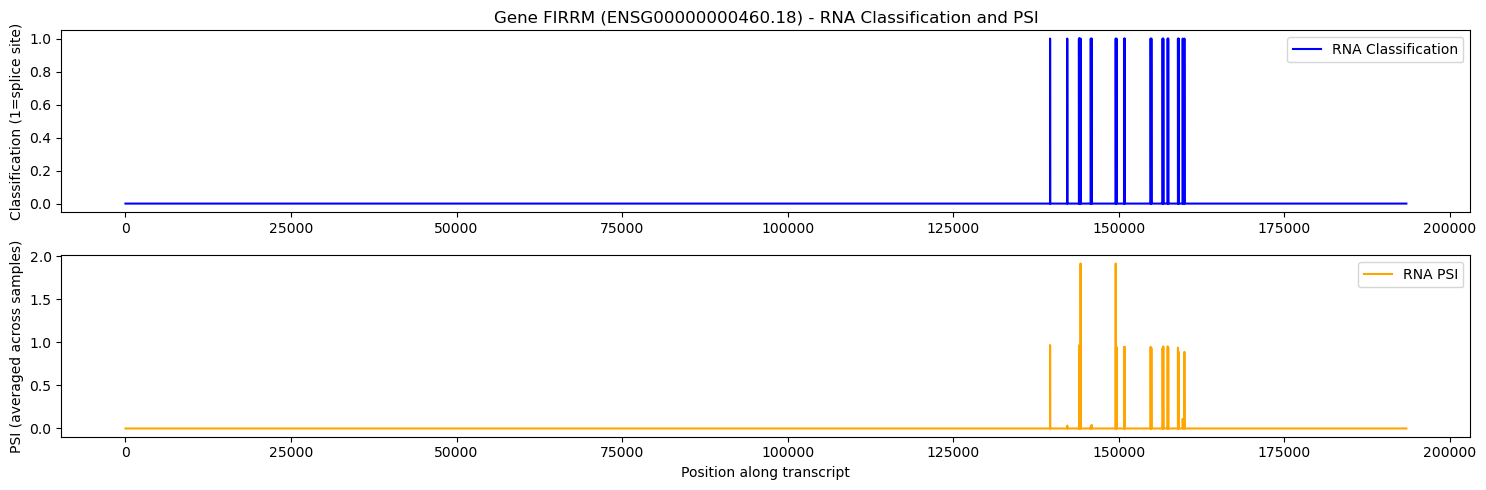

In [19]:
# plot the 1D array gene_lsv['rna_cls'] and gene_lsv['rna_psi'] with matplotlib
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 5))
plt.subplot(2, 1, 1)
plt.plot(gene_lsv['rna_cls'], label='RNA Classification', color='blue')
plt.title(f"Gene {gene_lsv['gene_name']} ({gene_lsv['gene_id']}) - RNA Classification and PSI")
plt.ylabel('Classification (1=splice site)')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(gene_lsv['rna_psi'], label='RNA PSI', color='orange')
plt.xlabel('Position along transcript')
plt.ylabel('PSI (averaged across samples)')
plt.legend()
plt.tight_layout()
plt.show()
                                                    

In [ ]:
### Step 1: merge expression

GEX_files = glob.glob("raw_data/gene_count/*counts.txt")
# Initialize empty list to collect dataframes
batch_list = []

for filepath in GEX_files:
    # Use filename (without extension) as sample name
    sample_name = filepath.split("/")[-1].split(".")[0]
    
    # Read file with gene ID as index
    df = pd.read_csv(filepath, sep="\t", header=None, index_col=0)
    df.columns = [sample_name]  # Rename single column to sample name
    
    batch_list.append(df)

# Merge all DataFrames on index (gene ID)
merged_df = pd.concat(batch_list, axis=1)

# Result: rows = genes, columns = samples
print("Merged expression matrix shape:", merged_df.shape)

# Step 2: Load database
db = gffutils.FeatureDB(gtf_db)

# Step 3: Calculate gene lengths (union of exon intervals per gene)
gene_lengths = {}
for gene_id in db.features_of_type('gene'):
    try:
        exons = list(db.children(gene_id, featuretype='exon', order_by='start'))
        if not exons:
            continue
        # Union exon spans
        intervals = []
        for exon in exons:
            intervals.append((exon.start, exon.end))
        # Merge overlapping intervals
        intervals.sort()
        merged = []
        current_start, current_end = intervals[0]
        for rna_start, rna_end in intervals[1:]:
            if rna_start <= current_end:
                current_end = max(current_end, rna_end)
            else:
                merged.append((current_start, current_end))
                current_start, current_end = rna_start, rna_end
        merged.append((current_start, current_end))
        # Sum total length
        total_length = sum(end - start + 1 for start, end in merged)
        gene_lengths[gene_id.id] = total_length
    except Exception as e:
        print(f"Failed on gene {gene_id.id}: {e}")

# Step 4: Save as TSV
length_df = pd.DataFrame.from_dict(gene_lengths, orient='index', columns=['length'])
length_df.index.name = 'gene_id'
length_df.to_csv("gencode.v48.gene_lengths.tsv", sep='\t')

# Load expression matrix
# Rows = genes, Columns = samples
expr_df = merged_df.iloc[0:-5, :]

# Load gene lengths (must match index of expr_df)
# Example format: gene_id \t length
gene_lengths = length_df['length']

# Filter to common genes
common_genes = expr_df.index.intersection(gene_lengths.index)
expr_df = expr_df.loc[common_genes]
gene_lengths = gene_lengths.loc[common_genes]

# Normalize counts to TPM
def counts_to_tpm(counts, lengths):
    rpk = counts.div(lengths, axis=0)  # reads per kilobase
    scaling_factor = rpk.sum(axis=0) / 1e6  # per sample
    return rpk.div(scaling_factor, axis=1)

tpm_df = counts_to_tpm(expr_df, gene_lengths)

# Save result
tpm_df.to_csv("combined_expression_matrix.TPM.tsv", sep='\t', float_format='%.3f')

In [3]:
## read expression table for generation
tpm_df = pd.read_csv("combined_expression_matrix.TPM.tsv", sep='\t').set_index('gene_id')
gene_select = tpm_df.std(axis = 1).nlargest(10).index

tpm_df = tpm_df.loc[gene_select, :]
normalized_df = tpm_df.sub(tpm_df.min(axis=1), axis=0).div(tpm_df.max(axis=1) - tpm_df.min(axis=1), axis=0).fillna(0)
normalized_df = normalized_df.round(3)

#normalized_df.to_csv("var_top10_exp.TPM.tsv", sep='\t')

In [ ]:
def Write_Training_Data_From_EXP_PSI(normalized_df, _out_path="default_training_data.pt"):
    training_input = []
    training_label = []
    genome = Fasta(genome_fasta)

    for sample_id in normalized_df.columns:
        print(f"Processing sample: {sample_id}")
    
        # Find TSV files matching this sample_id
        tsv_files = glob.glob(f"raw_data/PSI/*{sample_id}*.psi.tsv")
        if not tsv_files:
            print(f"  No PSI TSV files found for sample {sample_id}, skipping.")
            continue
    
        for MAJIQ_TSV in tsv_files:
            #print(f"  Processing file: {MAJIQ_TSV}")
            try:
                majiq_df = pd.read_csv(MAJIQ_TSV, sep="\s+")[0:25]  # optionally limit for speed
            except Exception as e:
                print(f"Failed to load {MAJIQ_TSV}: {e}")
                continue

            # Group rows by gene_id
            gene_groups = defaultdict(list)
            for _, row in majiq_df.iterrows():
                gene_groups[row['gene_id']].append(row)

            for gene, rows in gene_groups.items():
                psi_map = {}
                # Merge PSI values from all LSVs of the same gene
                for row in rows:
                    psi_values = list(map(float, row['mean_psi_per_lsv_junction'].split(';')))
                    junction_coords = row['junctions_coords'].split(';')
                    for junc, psi in zip(junction_coords, psi_values):
                        try:
                            start, end = parse_coords(junc)
                            psi_map[start] = psi
                            psi_map[end] = psi
                        except Exception as e:
                            print(f"Failed to parse junction '{junc}': {e}")
                            continue
            
                # Get gene region
                result = get_gene_bounds_by_id(gene, gtf_db)
                if result is None:
                    print(f"Skipping {gene} – gene bounds not found.")
                    continue
                chrom, strand, tss, tes = result
                #print(f"Gene: {gene} – Coordinates: {chrom} {strand} {tss} {tes}")

                # Get expression vector for this block by sample
                expr_vec = normalized_df.loc[:, sample_id].values  # shape: (10,)
                expr_tensor = torch.tensor(expr_vec, dtype=torch.float32).view(-1, 1).repeat(1, BLOCK_SIZE)  # [10, 15000]
                
                # Create sequence blocks
                start = min(tss, tes)
                end = max(tss, tes)
                blocks = make_blocks(start, end, chrom, genome, PADDING, BLOCK_SIZE)
                
                for block_start, block_end, seq in blocks:
                    if seq.count('N')>= PADDING:
                        print (seq.count('N'), "out of ", BLOCK_SIZE, "Skip")
                        continue
                    seq_tensor = torch.tensor(one_hot_encode(seq), dtype=torch.float32)  # [4, 15000]
                    X = torch.cat([seq_tensor, expr_tensor], dim=0)  # [14, 15000]
                    y = torch.tensor(assign_labels(block_start, block_end, psi_map, PADDING, BLOCK_SIZE), dtype=torch.float32)
                    training_input.append(X)
                    training_label.append(y)
    torch.save({'X': training_input, 'y': training_label}, _out_path)
    print(f"Saved {len(training_input)} samples to {_out_path}")
    return None

In [10]:
normalized_df = pd.read_csv("var_top10_exp.TPM.tsv", sep='\t').set_index('gene_id')
#normalized_df = normalized_df.iloc[:, 0:20] 
normalized_df = normalized_df.loc[:, ["2027sTS"]] #
output_name = "Top10_20S_training_data_sequece_exp.pt"
Write_Training_Data_From_EXP_PSI(normalized_df, output_name)#"Top10_20S_training_data_sequece_exp.pt")

Processing sample: 5818sTS
Processing sample: 3672sTS
Processing sample: 1443sTSm
Processing sample: 5952sTS
9896 out of  15000 Skip
14896 out of  15000 Skip
15000 out of  15000 Skip
15000 out of  15000 Skip
15000 out of  15000 Skip
15000 out of  15000 Skip
15000 out of  15000 Skip
15000 out of  15000 Skip
15000 out of  15000 Skip
10104 out of  15000 Skip
5104 out of  15000 Skip
Processing sample: 5905sTS
Processing sample: 2110sTS
Processing sample: 5645sTS
Processing sample: 6100sTS
Processing sample: 2113sTS
Processing sample: 3589sTS
Processing sample: 5942sTS
9896 out of  15000 Skip
14896 out of  15000 Skip
15000 out of  15000 Skip
15000 out of  15000 Skip
15000 out of  15000 Skip
15000 out of  15000 Skip
15000 out of  15000 Skip
15000 out of  15000 Skip
15000 out of  15000 Skip
10104 out of  15000 Skip
5104 out of  15000 Skip
Processing sample: 5822sTS
Processing sample: 5664sTS
Processing sample: 3643sTS
Processing sample: 5628sTS
Processing sample: 6107sTS
Processing sample: 35

In [22]:
!aws s3 cp Top10_20S_training_data_sequece_exp.pt s3://research.luffingfuturellc/Pangolin/

upload: ./Top10_20S_training_data_sequece_exp.pt to s3://research.luffingfuturellc/Pangolin/Top10_20S_training_data_sequece_exp.pt


## validation from PSI to Label

In [6]:
def Plot_2D_Array(array):
    ## 2D torch tensor, shape =  torch.Size([3, 15000])
    # Plot
    fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
    colors = ['gray', 'blue', 'red']
    labels = ['Un', 'S', 'Usage']
    # X-axis (sequence positions)
    x = np.arange(len(array[0]))
    
    for i in range(3):
        axes[i].plot(x, array[i], color = colors[i])
        axes[i].set_ylabel(labels[i])
        axes[i].set_ylim(0, 1)
        axes[i].grid(True)
    
    axes[-1].set_xlabel("Sequence Position")
    fig.suptitle("Individual Class Predictions Over Sequence", y=1.02)
    plt.tight_layout()
    plt.show()
    return None

0


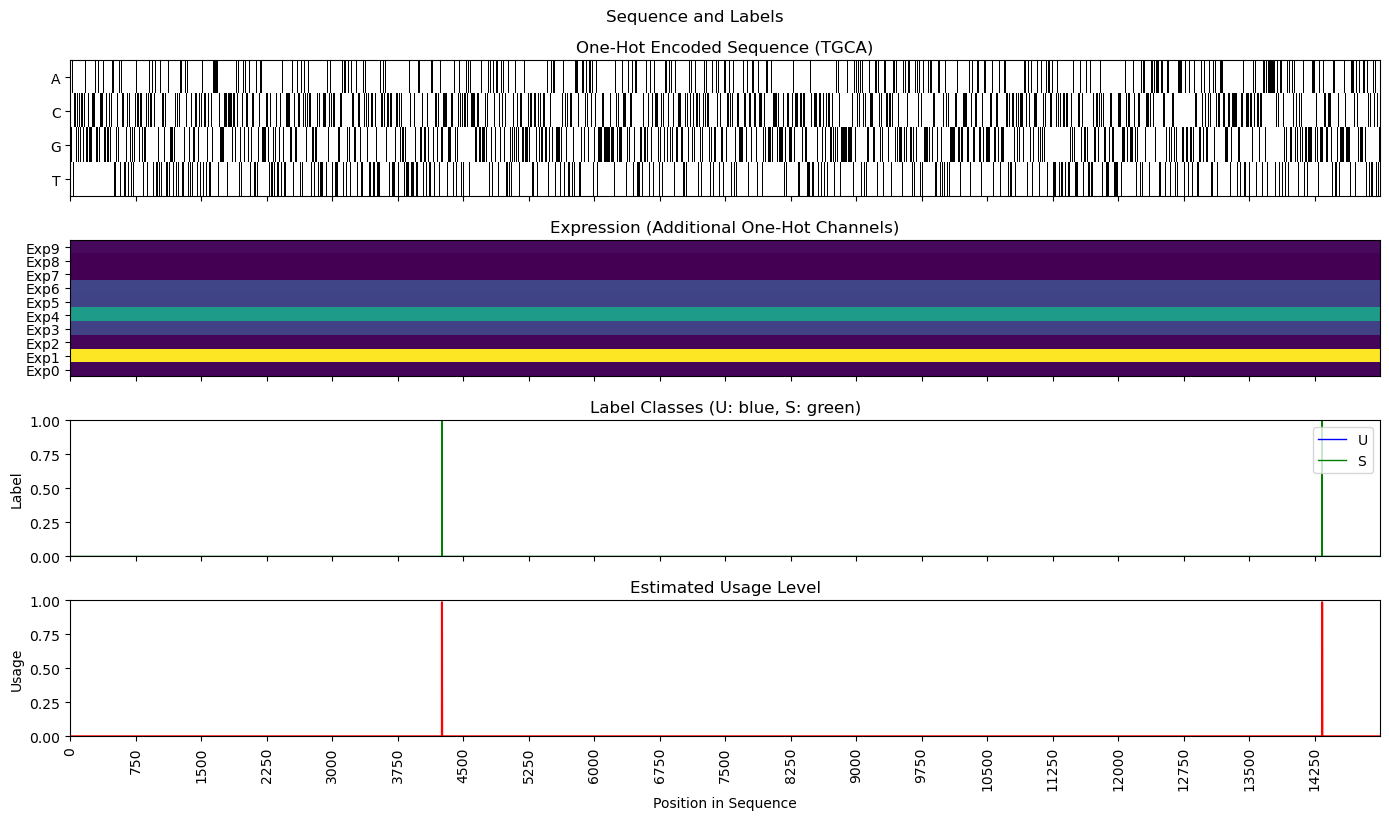

1


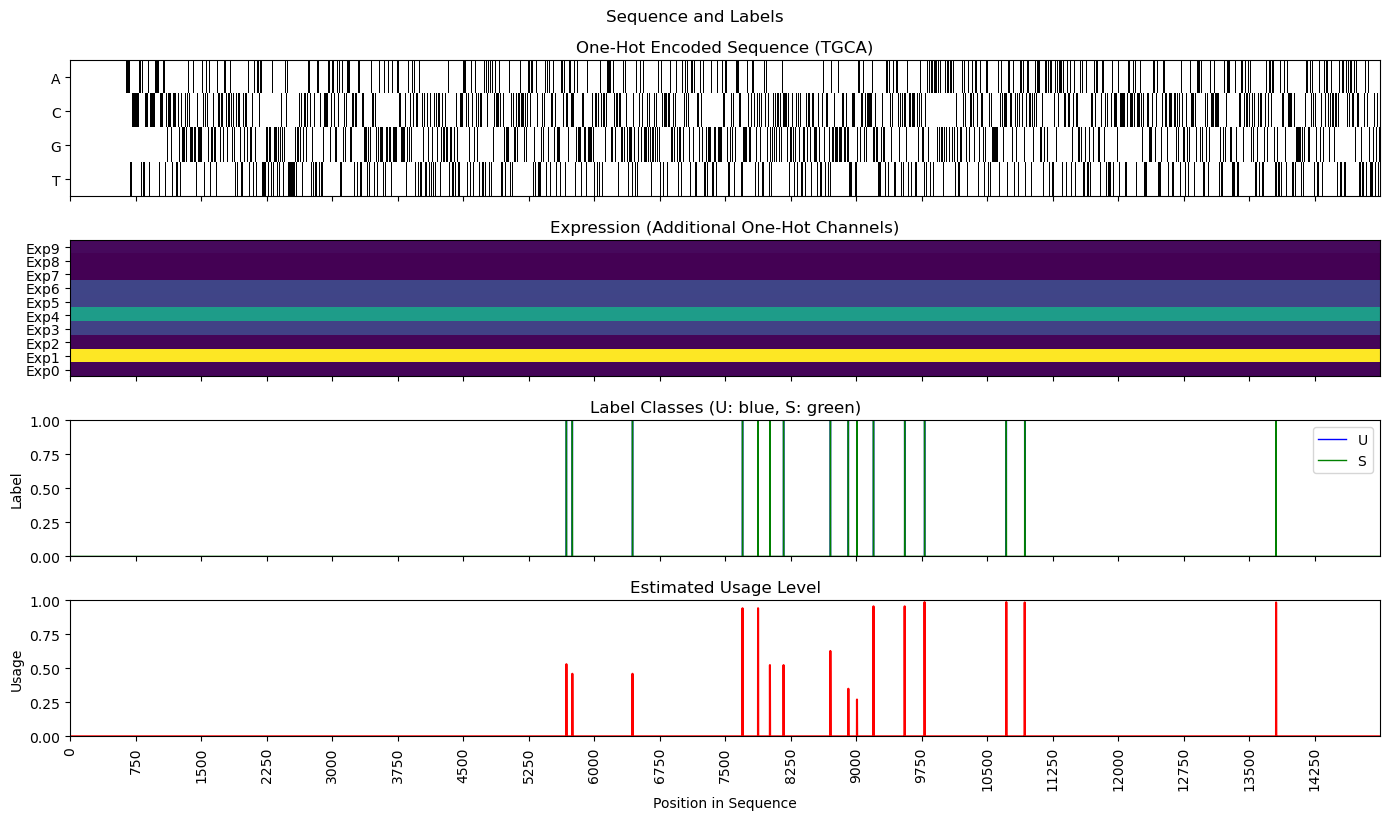

In [9]:
## BCE weight = 1
cor_start = 0
cor_end = 15000 #7704

for i in range(0, 2, 1):
    print (i)
    plot_one_hot_and_labels_zoom(training_input[i], training_label[i], 
                             zoom_start=cor_start, zoom_end=cor_end, title="Sequence and Labels")
    #break